In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.path.exists('/content/drive/MyDrive/Thesis_dataset.zip')

True

In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


In [ ]:
import shutil
import zipfile

# Copy from Drive to local storage
shutil.copy('/content/drive/MyDrive/Thesis_dataset.zip', '/content/Thesis_dataset.zip')
print("Copy done!")

# Extract
with zipfile.ZipFile('/content/Thesis_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction done!")

Copy done!
Extraction done!


In [ ]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files[:5]:
        print(f'{indent}  {f}')
    if len(files) > 5:
        print(f'{indent}  ... and {len(files) - 5} more files')

dataset/
  agrivision_dataset/
    .DS_Store
    Corn/
      .DS_Store
      Corn_Gray_Leaf_Spot/
        Corn_Gray_Leaf_Spot1832.JPG
        Corn_Gray_Leaf_Spot1794.JPG
        Corn_Gray_Leaf_Spot269.jpg
        Corn_Gray_Leaf_Spot877.JPG
        Corn_Gray_Leaf_Spot2129.JPG
        ... and 2196 more files
      Corn_Healthy/
        Corn_Healthy1339.jpg
        Corn_Healthy397.jpg
        Corn_Healthy1952.jpg
        Corn_Healthy1735.jpg
        Corn_Healthy22.jpg
        ... and 2196 more files
      Corn_Common_Rust/
        Corn_Common_Rust278.JPG
        Corn_Common_Rust117.JPG
        Corn_Common_Rust2025.JPG
        Corn_Common_Rust934.JPG
        Corn_Common_Rust1891.JPG
        ... and 2196 more files
      Corn_Leaf_Blight/
        Corn_Leaf_Blight2076.JPG
        Corn_Leaf_Blight1621.JPG
        Corn_Leaf_Blight1506.JPG
        Corn_Leaf_Blight1417.JPG
        Corn_Leaf_Blight1044.JPG
        ... and 2196 more files
    Wheat/
      .DS_Store
      Wheat_Yellow_Rust/
       

In [ ]:
!apt-get install -y tree -qq
!tree -L 3 /content/dataset

Selecting previously unselected package tree.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/dataset
├── agrivision_dataset
│   ├── Corn
│   │   ├── Corn_Common_Rust
│   │   ├── Corn_Gray_Leaf_Spot
│   │   ├── Corn_Healthy
│   │   └── Corn_Leaf_Blight
│   ├── Rice
│   │   ├── Rice_Bacterial_Leaf_Blight
│   │   ├── Rice_Brown_Spot
│   │   ├── Rice_Healthy
│   │   └── Rice_Leaf_Blast
│   └── Wheat
│       ├── Wheat_Brown_Rust
│       ├── Wheat_Healthy
│       ├── Wheat_Loose_Smut
│       └── Wheat_Yellow_Rust
└── __MACOSX
    └── agrivision_dataset
        ├── Corn
        ├── Rice
        └── Wheat

21 directories, 0 files


In [ ]:
import os

base_path = '/content/dataset/agrivision_dataset'

total_images = 0
class_counts = {}

for crop in sorted(os.listdir(base_path)):
    crop_path = os.path.join(base_path, crop)
    if not os.path.isdir(crop_path):
        continue
    print(f"\n{crop}:")
    for disease_class in sorted(os.listdir(crop_path)):
        class_path = os.path.join(crop_path, disease_class)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
            class_counts[disease_class] = count
            total_images += count
            print(f"  {disease_class}: {count} images")

print(f"\n{'='*40}")
print(f"Total classes: {len(class_counts)}")
print(f"Total images: {total_images}")


Corn:
  Corn_Common_Rust: 2200 images
  Corn_Gray_Leaf_Spot: 2200 images
  Corn_Healthy: 2200 images
  Corn_Leaf_Blight: 2200 images

Rice:
  Rice_Bacterial_Leaf_Blight: 2200 images
  Rice_Brown_Spot: 2200 images
  Rice_Healthy: 2200 images
  Rice_Leaf_Blast: 2200 images

Wheat:
  Wheat_Brown_Rust: 2200 images
  Wheat_Healthy: 2200 images
  Wheat_Loose_Smut: 2191 images
  Wheat_Yellow_Rust: 2200 images

Total classes: 12
Total images: 26391


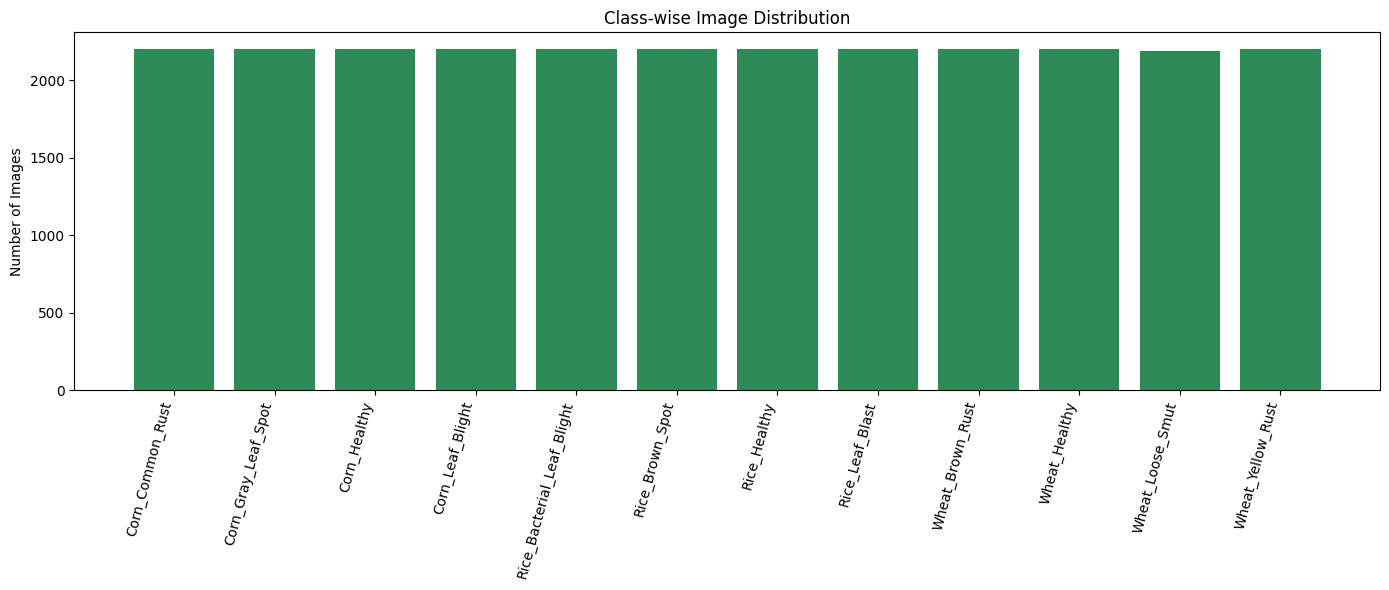

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='seagreen')
plt.xticks(rotation=75, ha='right')
plt.ylabel('Number of Images')
plt.title('Class-wise Image Distribution')
plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

base_path = '/content/dataset/agrivision_dataset'
corrupted_files = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

for crop in os.listdir(base_path):
    crop_path = os.path.join(base_path, crop)
    if not os.path.isdir(crop_path):
        continue
    for disease_class in os.listdir(crop_path):
        class_path = os.path.join(crop_path, disease_class)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)

            # Junk file check
            if not fname.lower().endswith(valid_extensions):
                corrupted_files.append(fpath)
                continue

            # Corrupted image check
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                corrupted_files.append(fpath)

print(f"Total corrupted/junk files found: {len(corrupted_files)}")
for f in corrupted_files[:20]:
    print(f)

Total corrupted/junk files found: 21
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/.DS_Store
/content/dataset/agrivision_dataset/Corn/Corn_Healthy/.DS_Store
/content/dataset/agrivision_dataset/Corn/Corn_Common_Rust/.DS_Store
/content/dataset/agrivision_dataset/Corn/Corn_Leaf_Blight/.DS_Store
/content/dataset/agrivision_dataset/Wheat/Wheat_Yellow_Rust/.DS_Store
/content/dataset/agrivision_dataset/Wheat/Wheat_Brown_Rust/.DS_Store
/content/dataset/agrivision_dataset/Wheat/Wheat_Healthy/.DS_Store
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Smut645.gif
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Smut328.gif
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Smut336.gif
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Smut636.gif
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Smut81.gif
/content/dataset/agrivision_dataset/Wheat/Wheat_Loose_Smut/Wheat_Loose_Sm

In [ ]:
import hashlib

hashes = {}
duplicates = []

for crop in os.listdir(base_path):
    crop_path = os.path.join(base_path, crop)
    if not os.path.isdir(crop_path):
        continue
    for disease_class in os.listdir(crop_path):
        class_path = os.path.join(crop_path, disease_class)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)

            if fpath in corrupted_files:
                continue

            with open(fpath, 'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()

            if h in hashes:
                duplicates.append(fpath)
            else:
                hashes[h] = fpath

print(f"Total duplicate files found: {len(duplicates)}")
for f in duplicates[:20]:
    print(f)

Total duplicate files found: 9557
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot806.jpg
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1511.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1417.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot793.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1387.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot951.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1858.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1518.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot861.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot1948.JPG
/content/dataset/agrivision_dataset/Corn/Corn_Gray_Leaf_Spot/Corn_Gray_Leaf_Spot

In [ ]:
from collections import Counter

# Count duplicates per class
dup_class_counts = Counter()

for f in duplicates:
    parts = f.split('/')
    disease_class = parts[-2]   # get class name from parent folder
    dup_class_counts[disease_class] += 1

# Print duplicate percentage per class
for cls, cnt in sorted(dup_class_counts.items(), key=lambda x: -x[1]):
    original_count = class_counts.get(cls, 0)
    print(f"{cls}: {cnt} duplicates out of {original_count} total ({cnt/original_count*100:.1f}%)")

Wheat_Loose_Smut: 1665 duplicates out of 2191 total (76.0%)
Corn_Leaf_Blight: 1056 duplicates out of 2200 total (48.0%)
Corn_Healthy: 1038 duplicates out of 2200 total (47.2%)
Corn_Gray_Leaf_Spot: 1028 duplicates out of 2200 total (46.7%)
Wheat_Brown_Rust: 979 duplicates out of 2200 total (44.5%)
Wheat_Yellow_Rust: 924 duplicates out of 2200 total (42.0%)
Corn_Common_Rust: 894 duplicates out of 2200 total (40.6%)
Wheat_Healthy: 829 duplicates out of 2200 total (37.7%)
Rice_Leaf_Blast: 493 duplicates out of 2200 total (22.4%)
Rice_Brown_Spot: 403 duplicates out of 2200 total (18.3%)
Rice_Bacterial_Leaf_Blight: 245 duplicates out of 2200 total (11.1%)
Rice_Healthy: 3 duplicates out of 2200 total (0.1%)


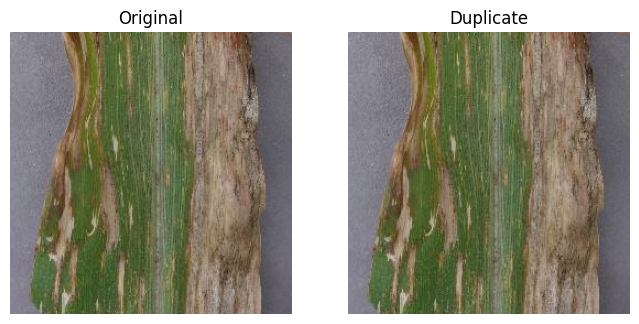

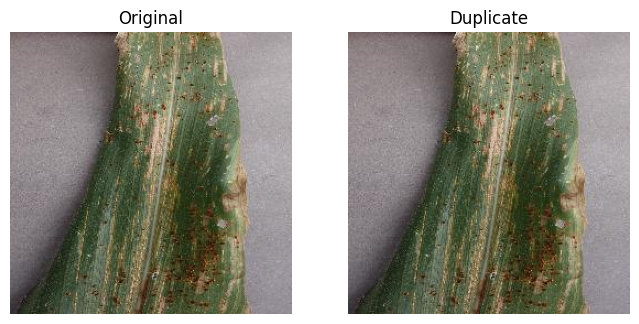

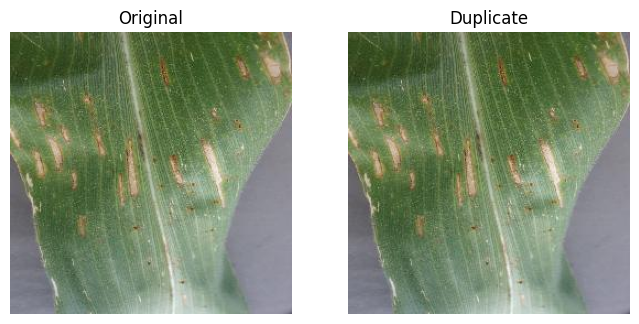

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Check first 3 duplicate pairs visually
sample_dupes = duplicates[:3]

for dup_path in sample_dupes:
    with open(dup_path, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    original_path = hashes[h]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(Image.open(original_path))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(Image.open(dup_path))
    axes[1].set_title('Duplicate')
    axes[1].axis('off')
    plt.show()

In [ ]:
files_to_delete = corrupted_files + duplicates

for f in files_to_delete:
    try:
        os.remove(f)
    except FileNotFoundError:
        pass

# Summary
print(f"Deleted {len(corrupted_files)} corrupted/junk files")
print(f"Deleted {len(duplicates)} duplicate files")
print(f"Total deleted: {len(files_to_delete)}")

Deleted 21 corrupted/junk files
Deleted 9557 duplicate files
Total deleted: 9578


In [ ]:
class_counts_after = {}
total_after = 0

for crop in sorted(os.listdir(base_path)):
    crop_path = os.path.join(base_path, crop)
    if not os.path.isdir(crop_path):
        continue
    for disease_class in sorted(os.listdir(crop_path)):
        class_path = os.path.join(crop_path, disease_class)
        if os.path.isdir(class_path):
            # Count only valid image files
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
            class_counts_after[disease_class] = count
            total_after += count

for cls, cnt in class_counts_after.items():
    print(f"{cls}: {cnt}")

print(f"\nTotal images after cleaning: {total_after}")

Corn_Common_Rust: 1306
Corn_Gray_Leaf_Spot: 1172
Corn_Healthy: 1162
Corn_Leaf_Blight: 1144
Rice_Bacterial_Leaf_Blight: 1955
Rice_Brown_Spot: 1797
Rice_Healthy: 2197
Rice_Leaf_Blast: 1707
Wheat_Brown_Rust: 1221
Wheat_Healthy: 1371
Wheat_Loose_Smut: 526
Wheat_Yellow_Rust: 1276

Total images after cleaning: 16834


In [ ]:
import os
import shutil

base_path = '/content/dataset/agrivision_dataset'
flat_path = '/content/flat_dataset'

os.makedirs(flat_path, exist_ok=True)

for crop in os.listdir(base_path):
    crop_path = os.path.join(base_path, crop)
    if not os.path.isdir(crop_path):
        continue
    for disease_class in os.listdir(crop_path):
        class_path = os.path.join(crop_path, disease_class)
        if not os.path.isdir(class_path):
            continue

        # Destination folder named after the disease class only
        dest_class_path = os.path.join(flat_path, disease_class)
        os.makedirs(dest_class_path, exist_ok=True)

        for fname in os.listdir(class_path):
            src = os.path.join(class_path, fname)
            dst = os.path.join(dest_class_path, fname)
            shutil.copy2(src, dst)

print("Flattening done!")

Flattening done!


In [ ]:
for cls in sorted(os.listdir(flat_path)):
    cls_path = os.path.join(flat_path, cls)
    count = len(os.listdir(cls_path))
    print(f"{cls}: {count}")

Corn_Common_Rust: 1306
Corn_Gray_Leaf_Spot: 1172
Corn_Healthy: 1162
Corn_Leaf_Blight: 1144
Rice_Bacterial_Leaf_Blight: 1955
Rice_Brown_Spot: 1797
Rice_Healthy: 2197
Rice_Leaf_Blast: 1707
Wheat_Brown_Rust: 1221
Wheat_Healthy: 1371
Wheat_Loose_Smut: 526
Wheat_Yellow_Rust: 1276


In [ ]:
import splitfolders

splitfolders.ratio(flat_path, output='/content/split_dataset',
                    seed=42, ratio=(0.7, 0.15, 0.15))
print("Split done!")

Copying files: 16834 files [00:18, 888.41 files/s] 

Split done!


In [ ]:
train_path = '/content/split_dataset/train'

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    print(f"{cls}: {len(os.listdir(cls_path))}")

Corn: 0
Corn_Common_Rust: 914
Corn_Gray_Leaf_Spot: 820
Corn_Healthy: 813
Corn_Leaf_Blight: 800
Rice: 0
Rice_Bacterial_Leaf_Blight: 1368
Rice_Brown_Spot: 1257
Rice_Healthy: 1537
Rice_Leaf_Blast: 1194
Wheat: 0
Wheat_Brown_Rust: 854
Wheat_Healthy: 959
Wheat_Loose_Smut: 368
Wheat_Yellow_Rust: 893


In [ ]:
for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

Corn: 0
Corn_Common_Rust: 914
Corn_Gray_Leaf_Spot: 820
Corn_Healthy: 813
Corn_Leaf_Blight: 800
Rice: 0
Rice_Bacterial_Leaf_Blight: 1368
Rice_Brown_Spot: 1257
Rice_Healthy: 1537
Rice_Leaf_Blast: 1194
Wheat: 0
Wheat_Brown_Rust: 854
Wheat_Healthy: 959
Wheat_Loose_Smut: 368
Wheat_Yellow_Rust: 893


In [ ]:
import tensorflow as tf

augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.25),
    tf.keras.layers.RandomContrast(0.25),
    tf.keras.layers.RandomBrightness(0.25),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# Fixed target count per class in train set
TARGET_PER_CLASS_TRAIN = 1500

train_class_counts = {}
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    if not os.path.isdir(cls_path) or len(os.listdir(cls_path)) == 0:
        continue
    train_class_counts[cls] = len(os.listdir(cls_path))

for cls, count in train_class_counts.items():
    cls_path = os.path.join(train_path, cls)
    images = os.listdir(cls_path)
    needed = TARGET_PER_CLASS_TRAIN - count

    if needed <= 0:
        print(f"{cls}: already has {count}, skipping (target reached or exceeded)")
        continue

    print(f"Augmenting {cls}: {count} -> {TARGET_PER_CLASS_TRAIN} (generating {needed} images)")

    generated = 0
    idx = 0
    while generated < needed:
        img_name = images[idx % len(images)]
        img_path = os.path.join(cls_path, img_name)

        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)

        aug_img = augmenter(img_array, training=True)
        aug_img = tf.squeeze(aug_img, 0).numpy().astype('uint8')

        save_name = f"aug_{generated}_{img_name}"
        save_path = os.path.join(cls_path, save_name)
        tf.keras.utils.save_img(save_path, aug_img)

        generated += 1
        idx += 1

print("\nBalancing done!")

Augmenting Corn_Gray_Leaf_Spot: 820 -> 1500 (generating 680 images)
Augmenting Wheat_Yellow_Rust: 893 -> 1500 (generating 607 images)
Augmenting Wheat_Brown_Rust: 854 -> 1500 (generating 646 images)
Augmenting Rice_Leaf_Blast: 1194 -> 1500 (generating 306 images)
Augmenting Corn_Healthy: 813 -> 1500 (generating 687 images)
Augmenting Corn_Common_Rust: 914 -> 1500 (generating 586 images)
Augmenting Rice_Brown_Spot: 1257 -> 1500 (generating 243 images)
Rice_Healthy: already has 1537, skipping (target reached or exceeded)
Augmenting Wheat_Healthy: 959 -> 1500 (generating 541 images)
Augmenting Wheat_Loose_Smut: 368 -> 1500 (generating 1132 images)
Augmenting Corn_Leaf_Blight: 800 -> 1500 (generating 700 images)
Augmenting Rice_Bacterial_Leaf_Blight: 1368 -> 1500 (generating 132 images)

Balancing done!


In [5]:
import os

train_path = '/content/split_dataset/train'

total = 0
for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path) and len(os.listdir(cls_path)) > 0:
        count = len(os.listdir(cls_path))
        total += count
        print(f"{cls}: {count}")

print(f"\nTotal train images: {total}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/split_dataset/train'

In [ ]:
import os

for split in ['train', 'val', 'test']:
    split_path = f'/content/split_dataset/{split}'
    total = sum(len(os.listdir(os.path.join(split_path, cls)))
                for cls in os.listdir(split_path)
                if os.path.isdir(os.path.join(split_path, cls)))
    print(f"{split}: {total} images")

train: 18037 images
val: 2519 images
test: 2538 images


In [ ]:
import os
import pandas as pd

split_base = '/content/split_dataset'

for split in ['train', 'val', 'test']:
    split_path = os.path.join(split_base, split)
    data = []

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path) or len(os.listdir(cls_path)) == 0:
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            data.append({'filepath': fpath, 'label': cls})

    df = pd.DataFrame(data)
    csv_name = f'{split}_data.csv'
    df.to_csv(csv_name, index=False)
    print(f"{split}: {len(df)} rows saved to {csv_name}")

train: 18037 rows saved to train_data.csv
val: 2519 rows saved to val_data.csv
test: 2538 rows saved to test_data.csv


In [ ]:
import shutil

drive_csv_folder = '/content/drive/MyDrive/thesis_dataset_csv'
os.makedirs(drive_csv_folder, exist_ok=True)

for split in ['train', 'val', 'test']:
    src = f'{split}_data.csv'
    dst = os.path.join(drive_csv_folder, src)
    shutil.copy2(src, dst)

print("CSV files saved to Drive!")

CSV files saved to Drive!


In [ ]:
!zip -r /content/split_dataset.zip /content/split_dataset -q
shutil.copy2('/content/split_dataset.zip', '/content/drive/MyDrive/split_dataset.zip')
print("Full dataset backed up to Drive!")

Full dataset backed up to Drive!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile



if os.path.exists('/content/split_dataset'):
    print("✅ Split dataset আছে, সরাসরি count করছি...\n")
    for split in ['train', 'val', 'test']:
        split_path = f'/content/split_dataset/{split}'
        print(f"\n{'='*40}")
        print(f"📂 {split.upper()}")
        print(f"{'='*40}")
        total = 0
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path) and len(os.listdir(cls_path)) > 0:
                n = len(os.listdir(cls_path))
                total += n
                print(f"  {cls}: {n}")
        print(f"  {'─'*30}")
        print(f"  Total: {total}")
else:
    print("❌ /content/split_dataset..There is no content")
    print("upziping from drive...")
    with zipfile.ZipFile('/content/drive/MyDrive/split_dataset.zip', 'r') as z:
        z.extractall('/content/')
    print("Done!")

Mounted at /content/drive
❌ /content/split_dataset..There is no content
upziping from drive...
Done!


In [3]:
import os


for root, dirs, files in os.walk('/content'):
    for d in dirs:
        if d == 'train' or d == 'val' or d == 'test':
            print(os.path.join(root, d))

/content/val
/content/train
/content/test


In [4]:
import os

for split in ['train', 'val', 'test']:
    split_path = f'/content/{split}'
    print(f"\n{'='*40}")
    print(f"📂 {split.upper()}")
    print(f"{'='*40}")
    total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path) and len(os.listdir(cls_path)) > 0:
            n = len(os.listdir(cls_path))
            total += n
            print(f"  {cls}: {n}")
    print(f"  {'─'*30}")
    print(f"  Total: {total}")


📂 TRAIN
  Corn_Common_Rust: 1500
  Corn_Gray_Leaf_Spot: 1500
  Corn_Healthy: 1500
  Corn_Leaf_Blight: 1500
  Rice_Bacterial_Leaf_Blight: 1500
  Rice_Brown_Spot: 1500
  Rice_Healthy: 1537
  Rice_Leaf_Blast: 1500
  Wheat_Brown_Rust: 1500
  Wheat_Healthy: 1500
  Wheat_Loose_Smut: 1500
  Wheat_Yellow_Rust: 1500
  ──────────────────────────────
  Total: 18037

📂 VAL
  Corn_Common_Rust: 195
  Corn_Gray_Leaf_Spot: 175
  Corn_Healthy: 174
  Corn_Leaf_Blight: 171
  Rice_Bacterial_Leaf_Blight: 293
  Rice_Brown_Spot: 269
  Rice_Healthy: 329
  Rice_Leaf_Blast: 256
  Wheat_Brown_Rust: 183
  Wheat_Healthy: 205
  Wheat_Loose_Smut: 78
  Wheat_Yellow_Rust: 191
  ──────────────────────────────
  Total: 2519

📂 TEST
  Corn_Common_Rust: 197
  Corn_Gray_Leaf_Spot: 177
  Corn_Healthy: 175
  Corn_Leaf_Blight: 173
  Rice_Bacterial_Leaf_Blight: 294
  Rice_Brown_Spot: 271
  Rice_Healthy: 331
  Rice_Leaf_Blast: 257
  Wheat_Brown_Rust: 184
  Wheat_Healthy: 207
  Wheat_Loose_Smut: 80
  Wheat_Yellow_Rust: 192
  ──